# MNIST 손글씨 숫자 분류 (Classifcation)

## 1. 각종 환경 변수 설정


In [1]:
from pathlib import Path
import torch
from IPython.display import display
from PIL import Image

DATA = Path("/content/mnist") if Path("/content").exists() else Path.cwd() / "mnist_data"
RUNS = Path("/content/mnist_runs") if Path("/content").exists() else Path.cwd() / "mnist_runs"
DATA.mkdir(parents=True, exist_ok=True)
RUNS.mkdir(parents=True, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__)
print("device", DEVICE)
if DEVICE.type == "cuda":
    print("gpu", torch.cuda.get_device_name(0))


def show_img(img, width=900):
    img = img.convert("RGB")
    w, h = img.size
    if w > width:
        img = img.resize((width, int(h * width / w)), Image.NEAREST)
    display(img)


torch 2.14.0+cu130
device cuda
gpu NVIDIA GeForce RTX 3060


## 2. 데이터셋 구축

Total: 60,000
Train: 45000 / Validation: 5000 / Test: 10000


100.0%
100.0%
100.0%
100.0%

train 55000 val 5000 test 10000


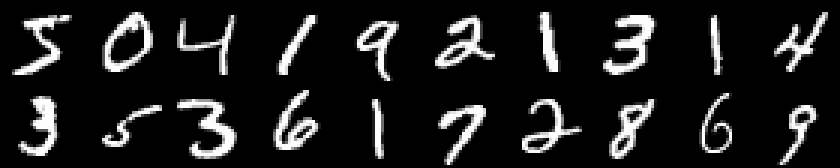

맨 앞 20 장. 왼쪽 위부터 오른쪽순으로 표시


In [2]:
import random

import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

EPOCHS = 5
BATCH = 128
LR = 1e-3
SEED = 42


def set_seed(seed):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


tf = transforms.ToTensor()
DATA.mkdir(parents=True, exist_ok=True)
full_train = datasets.MNIST(DATA, train=True, download=True, transform=tf)
test_ds = datasets.MNIST(DATA, train=False, download=True, transform=tf)

set_seed(SEED)
n_val = 5000
n_train = len(full_train) - n_val
train_ds, val_ds = random_split(
    full_train,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED),
)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False, num_workers=0)
print("train", n_train, "val", n_val, "test", len(test_ds))


def digit_to_pil(t):
    arr = (t.squeeze().numpy() * 255).clip(0, 255).astype("uint8")
    return Image.fromarray(arr, mode="L").resize((84, 84), Image.NEAREST)


def show_samples(dataset, n=20, cols=10):
    cell = 84
    rows = (n + cols - 1) // cols
    canvas = Image.new("RGB", (cols * cell, rows * cell), (20, 20, 20))
    for i in range(n):
        img, y = dataset[i]
        tile = digit_to_pil(img).convert("RGB")
        r, c = divmod(i, cols)
        canvas.paste(tile, (c * cell, r * cell))
    show_img(canvas, width=840)
    print("맨 앞", n, "장. 왼쪽 위부터 오른쪽순으로 표시")


show_samples(full_train)


## 3. 모델 구축
- `conv1`: 1→32, 해상도 유지 후 MaxPool로 14×14
- `conv2`: 32→64, 다시 MaxPool로 7×7
- `fc`: 64×7×7을 펼쳐 128을 거쳐 숫자 10개


In [3]:
from torch import nn


class DigitCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        return self.fc(x)


def show_cnn_shapes(model, h=28, w=28):
    model.eval()
    x = torch.zeros(1, 1, h, w)
    with torch.no_grad():
        c1 = model.conv1(x)
        c2 = model.conv2(c1)
        logits = model.fc(c2)
    for name, t in (("input", x), ("conv1+pool", c1), ("conv2+pool", c2), ("logits", logits)):
        print(f"{name:12s} {tuple(t.shape)}")
    n = sum(p.numel() for p in model.parameters())
    print(f"파라미터 {n:,}")


show_cnn_shapes(DigitCNN())


input        (1, 1, 28, 28)
conv1+pool   (1, 32, 14, 14)
conv2+pool   (1, 64, 7, 7)
logits       (1, 10)
파라미터 421,642


## 4. 학습 

검증 정확도로 `best.pt`를 저장, 학습이 끝난 후 테스트(10000장) 수행


In [4]:
import json

import torch
from torch import nn

set_seed(SEED)
model = DigitCNN().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
RUNS.mkdir(parents=True, exist_ok=True)


def accuracy(logits, y):
    return (logits.argmax(1) == y).float().mean().item()


def run_epoch(model, loader, train):
    model.train(train)
    total_loss, total_acc, n = 0.0, 0.0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        with torch.set_grad_enabled(train):
            logits = model(x)
            loss = criterion(logits, y)
            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
        bs = y.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy(logits.detach(), y) * bs
        n += bs
    return total_loss / n, total_acc / n


@torch.no_grad()
def eval_split(model, loader):
    model.eval()
    n_ok = n = 0
    per_ok = [0] * 10
    per_n = [0] * 10
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        pred = model(x).argmax(1)
        n += y.size(0)
        n_ok += int((pred == y).sum().item())
        for t, p in zip(y.tolist(), pred.tolist()):
            per_n[t] += 1
            if t == p:
                per_ok[t] += 1
    per = {str(i): (per_ok[i] / per_n[i] if per_n[i] else 0.0) for i in range(10)}
    return {"acc": n_ok / n if n else 0.0, "n": n, "per_class": per}


best_acc = -1.0
history = []
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, True)
    va_loss, va_acc = run_epoch(model, val_loader, False)
    history.append(
        {
            "epoch": epoch,
            "train_loss": round(tr_loss, 4),
            "train_acc": round(tr_acc, 4),
            "val_loss": round(va_loss, 4),
            "val_acc": round(va_acc, 4),
        }
    )
    print(
        f"epoch {epoch:03d}  train loss {tr_loss:.4f} acc {tr_acc:.3f}  "
        f"val loss {va_loss:.4f} acc {va_acc:.3f}"
    )
    if va_acc >= best_acc:
        best_acc = va_acc
        torch.save({"model": model.state_dict()}, RUNS / "best.pt")

(RUNS / "history.json").write_text(json.dumps(history, indent=2), encoding="utf-8")
print("saved", RUNS / "best.pt", "best_val_acc", round(best_acc, 4))

ckpt = torch.load(RUNS / "best.pt", map_location="cpu", weights_only=True)
model.load_state_dict(ckpt["model"])
print("held_out_test", eval_split(model, test_loader))


epoch 001  train loss 0.2630 acc 0.920  val loss 0.0792 acc 0.977
epoch 002  train loss 0.0598 acc 0.982  val loss 0.0526 acc 0.984
epoch 003  train loss 0.0409 acc 0.987  val loss 0.0523 acc 0.986
epoch 004  train loss 0.0319 acc 0.990  val loss 0.0591 acc 0.982
epoch 005  train loss 0.0252 acc 0.992  val loss 0.0364 acc 0.990
saved /home/loveiori/workspace/ai-lectures/mnist_runs/best.pt best_val_acc 0.9898
held_out_test {'acc': 0.9903, 'n': 10000, 'per_class': {'0': 0.9979591836734694, '1': 0.9991189427312775, '2': 0.9912790697674418, '3': 0.9891089108910891, '4': 0.9938900203665988, '5': 0.9899103139013453, '6': 0.9832985386221295, '7': 0.9902723735408561, '8': 0.9845995893223819, '9': 0.9821605550049554}}


## 5. 추론 테스트

- Testset에서 앞에서 수행한 20장의 예측결과를 표시(틀린 경우 빨간 테두리로 표시)
- 틀린 샘플만 따로 모아서 표시

테스트 앞 20장


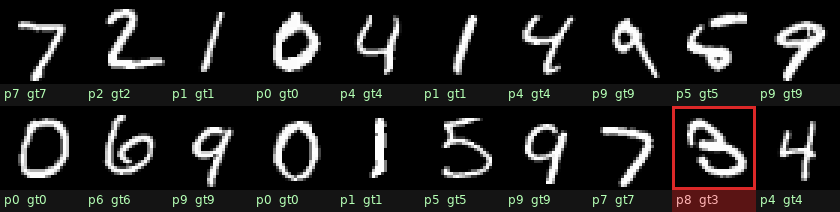


틀린 샘플 (최대 20장)


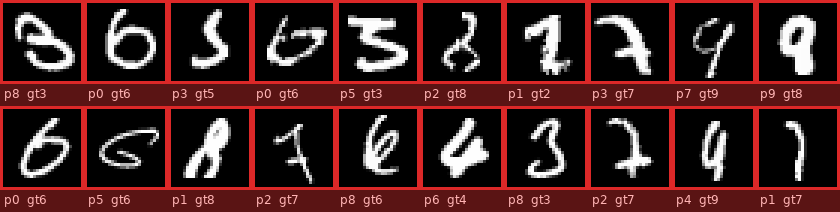

In [5]:
from PIL import ImageDraw, ImageFont


def font(size):
    for path in (
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf",
    ):
        try:
            return ImageFont.truetype(path, size)
        except OSError:
            continue
    return ImageFont.load_default()


def labeled_tile(img, pred, gt, size=84):
    ok = pred == gt
    tile = digit_to_pil(img).convert("RGB").resize((size, size), Image.NEAREST)
    canvas = Image.new("RGB", (size, size + 22), (20, 20, 20) if ok else (90, 20, 20))
    canvas.paste(tile, (0, 0))
    draw = ImageDraw.Draw(canvas)
    color = (180, 255, 180) if ok else (255, 180, 180)
    draw.text((4, size + 2), f"p{pred}  gt{gt}", fill=color, font=font(12))
    if not ok:
        draw.rectangle([0, 0, size - 1, size - 1], outline=(220, 40, 40), width=3)
    return canvas


def show_grid(items, cols=10, title=""):
    if not items:
        print(title, "없음")
        return
    cell_w, cell_h = items[0].size
    rows = (len(items) + cols - 1) // cols
    canvas = Image.new("RGB", (cols * cell_w, rows * cell_h), (12, 12, 12))
    for i, tile in enumerate(items):
        r, c = divmod(i, cols)
        canvas.paste(tile, (c * cell_w, r * cell_h))
    if title:
        print(title)
    show_img(canvas, width=min(980, cols * cell_w))


model = DigitCNN()
model.load_state_dict(torch.load(RUNS / "best.pt", map_location="cpu", weights_only=True)["model"])
model.eval()
model.to(DEVICE)

preview = []
wrong = []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        pred = model(x).argmax(1).cpu()
        for i in range(x.size(0)):
            tile = labeled_tile(x[i].cpu(), int(pred[i]), int(y[i]))
            if len(preview) < 20:
                preview.append(tile)
            if int(pred[i]) != int(y[i]) and len(wrong) < 20:
                wrong.append(tile)
        if len(preview) >= 20 and len(wrong) >= 20:
            break

show_grid(preview, title="테스트 앞 20장")
print()
show_grid(wrong, title="틀린 샘플 (최대 20장)")
